# Milestone 3: CLV / Churn Prediction

We build predictive models to estimate Customer Lifetime Value (CLV) and identify churned customers.

In [1]:
import pandas as pd

# Load cleaned dataset
df = pd.read_csv("../data/online_retail_cleaned.csv")
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,InvoiceYearMonth,InvoiceWeek,InvoiceDay
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12,48,2010-12-01
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,48,2010-12-01
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12,48,2010-12-01
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,48,2010-12-01
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,48,2010-12-01


In [2]:
# Compute CLV as total revenue per customer
clv_df = df.groupby('CustomerID').agg({
    'TotalPrice': 'sum',
    'InvoiceDate': 'max'
}).rename(columns={'TotalPrice': 'CLV', 'InvoiceDate': 'LastPurchase'})

# Reference date = last invoice + 1 day
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# Compute days since last purchase
clv_df['Recency'] = (reference_date - clv_df['LastPurchase']).dt.days

# Churn label: 1 if no purchase in last 90 days
clv_df['Churned'] = (clv_df['Recency'] > 90).astype(int)
clv_df = clv_df.drop(columns='LastPurchase')
clv_df.head()


,CLV,Recency,Churned
CustomerID,,,
12346.0,77183.60,326,1
12347.0,4310.00,2,0
12348.0,1797.24,75,0
12349.0,1757.55,19,0
12350.0,334.40,310,1


In [3]:
# Load RFM dataset
rfm = pd.read_csv("../data/rfm_clustered.csv")

# Merge on CustomerID
df_model = pd.merge(rfm, clv_df, on='CustomerID')
df_model.head()


,CustomerID,Recency_x,Frequency,Monetary,Cluster_KMeans,Cluster_GMM,Cluster_HDBSCAN,CLV,Recency_y,Churned
0,12346.0,326,1,77183.60,3,3,27,77183.60,326,1
1,12347.0,2,7,4310.00,0,0,24,4310.00,2,0
2,12348.0,75,4,1797.24,0,0,22,1797.24,75,0
3,12349.0,19,1,1757.55,0,0,19,1757.55,19,0
4,12350.0,310,1,334.40,1,1,3,334.40,310,1


In [4]:
from sklearn.model_selection import train_test_split

# Features and targets
X = df_model[['Recency_x', 'Frequency', 'Monetary']]
y_clv = df_model['CLV']
y_churn = df_model['Churned']

# Random split
X_train, X_test, y_clv_train, y_clv_test = train_test_split(X, y_clv, test_size=0.2, random_state=42)
_, _, y_churn_train, y_churn_test = train_test_split(X, y_churn, test_size=0.2, random_state=42)


In [7]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Train XGBoost model for CLV prediction
xgb_clf = XGBRegressor(n_estimators=100, random_state=42)
xgb_clf.fit(X_train, y_clv_train)

# Predict on test set
pred_xgb = xgb_clf.predict(X_test)

# Compute metrics
rmse = np.sqrt(mean_squared_error(y_clv_test, pred_xgb))
r2 = r2_score(y_clv_test, pred_xgb)

print(f"XGBoost CLV RMSE: {rmse:.2f}")
print(f"XGBoost CLV R2: {r2:.2f}")


XGBoost CLV RMSE: 4896.61
XGBoost CLV R2: 0.77


In [10]:
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Train LightGBM model
lgb_clf = LGBMRegressor(n_estimators=100, random_state=42)
lgb_clf.fit(X_train, y_clv_train)

# Predict on test set
pred_lgb = lgb_clf.predict(X_test)

# Compute metrics
rmse = np.sqrt(mean_squared_error(y_clv_test, pred_lgb))
r2 = r2_score(y_clv_test, pred_lgb)

print(f"LightGBM CLV RMSE: {rmse:.2f}")
print(f"LightGBM CLV R2: {r2:.2f}")


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000295 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 531
[LightGBM] [Info] Number of data points in the train set: 3470, number of used features: 3
[LightGBM] [Info] Start training from score 2012.939691
LightGBM CLV RMSE: 7171.51
LightGBM CLV R2: 0.50


In [11]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

xgb_cls = XGBClassifier(n_estimators=100, random_state=42)
xgb_cls.fit(X_train, y_churn_train)
pred_cls = xgb_cls.predict(X_test)

print("XGBoost Churn Classification Report:")
print(classification_report(y_churn_test, pred_cls))


XGBoost Churn Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       561
           1       1.00      1.00      1.00       307

    accuracy                           1.00       868
   macro avg       1.00      1.00      1.00       868
weighted avg       1.00      1.00      1.00       868



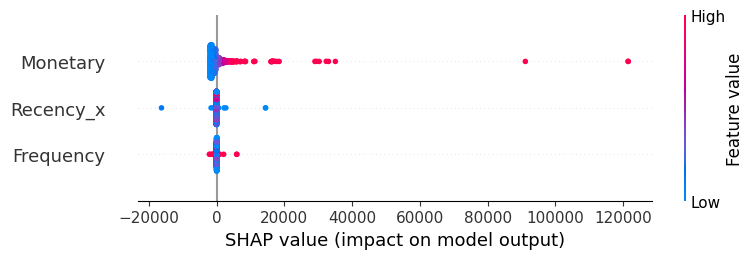

In [13]:
import shap

explainer = shap.Explainer(xgb_clf)
shap_values = explainer(X_test)

# Summary plot
shap.summary_plot(shap_values, X_test)


In [14]:
df_model.to_csv("../data/clv_churn_dataset.csv", index=False)
print("Model-ready dataset saved.")


Model-ready dataset saved.
